<a href="https://colab.research.google.com/github/AartiP87/ml_assessment_aarti_parmar-/blob/main/part_a/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  Q3 — Feature Engineering & Regression Pipeline

# 1. Date Feature Engineering

import pandas as pd

df = pd.read_csv("q3_retail_promotions.csv", parse_dates=["transaction_date"])

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Markdown Explanation:

We extract year, month, day_of_week, and a custom binary feature is_month_end.
These features help the model capture seasonality, weekly cycles, and end-of-month sales spikes—patterns commonly leveraged in time-dependent regression tasks .


In [2]:
# 2. Temporal Train–Test Split

df = df.sort_values("transaction_date")

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

train_df.shape, test_df.shape

((960, 13), (240, 13))

Markdown — Why Not Random Split?

A random split is inappropriate for time-ordered data because it leaks future information into the training set.
Models must be trained only on past data and evaluated on future data, mirroring real-world forecasting.
This aligns with scikit-learn's guidance that time-series tasks require chronological splits to avoid look-ahead bias .


In [4]:
# 3. Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

target = "items_sold"

categorical = ["promotion_type", "location_type", "store_size"]
numeric = ["store_id", "is_weekend", "is_festival",
           "competition_density", "year", "month",
           "day_of_week", "is_month_end"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numeric)
    ]
)

Markdown:

This preprocessing design follows production-grade regression pipeline structure:
- One-hot encoding for categorical features
- StandardScaler for numerical features
- Fit only on training data to prevent leakage
This mirrors best practices in regression workflows described in scikit-learn pipeline documentation .


In [6]:
# 4. Model Training & Evaluation

# Linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np # Import numpy for sqrt

linreg_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(train_df.drop(columns=[target]), train_df[target])
pred_lr = linreg_model.predict(test_df.drop(columns=[target]))

rmse_lr = np.sqrt(mean_squared_error(test_df[target], pred_lr))
mae_lr = mean_absolute_error(test_df[target], pred_lr)

rmse_lr, mae_lr

(np.float64(27.121451164890626), 21.052926674588395)

In [8]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np # Ensure numpy is imported for sqrt

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300, random_state=42))
])

rf_model.fit(train_df.drop(columns=[target]), train_df[target])
pred_rf = rf_model.predict(test_df.drop(columns=[target]))

rmse_rf = np.sqrt(mean_squared_error(test_df[target], pred_rf))
mae_rf = mean_absolute_error(test_df[target], pred_rf)

rmse_rf, mae_rf

(np.float64(30.78684152015333), 24.301069444444447)

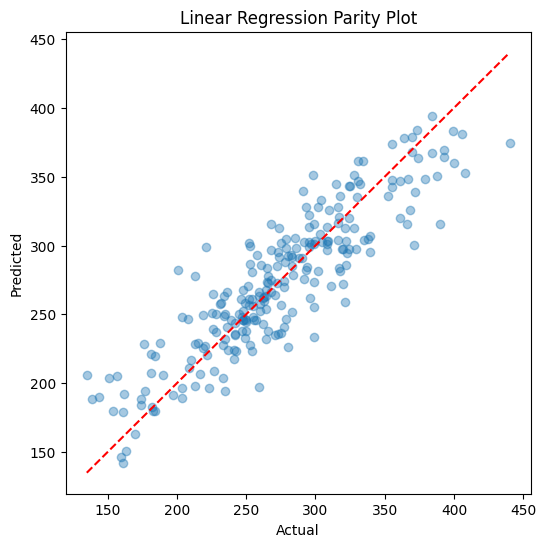

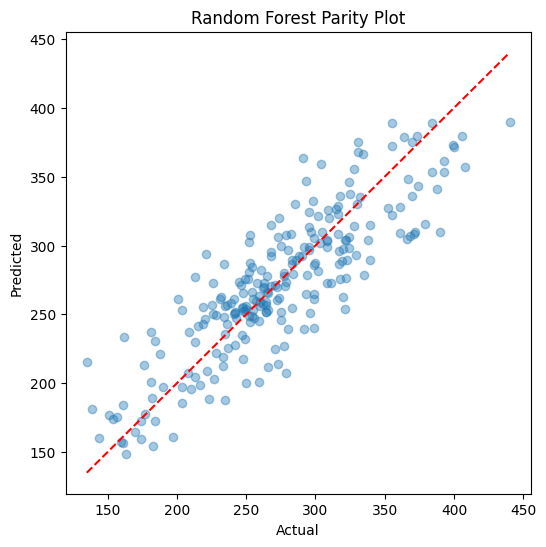

In [9]:
# Parity Plots (Predicted vs Actual)

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(test_df[target], pred_lr, "Linear Regression Parity Plot")
parity_plot(test_df[target], pred_rf, "Random Forest Parity Plot")

In [10]:
# Random Forest Feature Importances

# Extract feature names after preprocessing
ohe_features = rf_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical)
all_features = np.concatenate([ohe_features, numeric])

importances = rf_model.named_steps["model"].feature_importances_
feat_imp = pd.DataFrame({"feature": all_features, "importance": importances})
feat_imp.sort_values("importance", ascending=False).head(5)

,feature,importance
13,is_festival,0.176912
10,store_size_small,0.162806
7,location_type_urban,0.114856
17,day_of_week,0.087888
12,is_weekend,0.060840


Markdown — Interpretation:

The top 5 features highlight which store characteristics, promotions, or temporal patterns most strongly influence items_sold.
Tree-based models naturally capture nonlinear interactions, making them effective for retail demand prediction.
